**DATA CLEANING**

**1. Loading & Data Inspection**

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('/content/dynamic_supply_chain_logistics_dataset_with_country.csv')

# Periksa informasi umum dan missing values
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113097 entries, 0 to 113096
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   warehouse_inventory_level        113097 non-null  float64
 1   handling_equipment_availability  113097 non-null  float64
 2   order_fulfillment_status         113097 non-null  float64
 3   weather_condition_severity       113097 non-null  float64
 4   shipping_costs                   113097 non-null  float64
 5   supplier_reliability_score       113097 non-null  float64
 6   lead_time_days                   113097 non-null  float64
 7   historical_demand                113097 non-null  float64
 8   cargo_condition_status           113097 non-null  float64
 9   route_risk_level                 113097 non-null  float64
 10  customs_clearance_time           113097 non-null  float64
 11  disruption_likelihood_score      113097 non-null  float64
 12  de

**2. Data Cleaning & Handling Missing Values**

In [ ]:
# Mengisi missing values pada kolom numerik utama dengan median
numeric_cols = ['shipping_costs', 'lead_time_days', 'historical_demand', 'customs_clearance_time', 'delay_probability']
for col in numeric_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_979/2011743938.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


**3. Feature Engineering untuk Operational Efficiency**

In [ ]:
# 1. Status keterlambatan biner berdasarkan deviasi waktu pengiriman
df['Is_Delayed'] = np.where(df['delivery_time_deviation'] > 0, 1, 0)

# 2. Efisiensi Biaya: Biaya pengiriman per unit permintaan historis
df['Cost_per_Demand'] = df['shipping_costs'] / df['historical_demand'].replace(0, np.nan)

**4. Exploratory Data Analysis (EDA) untuk Insight Operasional**

In [ ]:
# Rata-rata biaya pengiriman, lead time, dan probabilitas delay berdasarkan negara supplier
print(df.groupby('supplier_country')[['shipping_costs', 'lead_time_days', 'delay_probability']].mean())

# Melihat hubungan antara reliabilitas supplier dan probabilitas keterlambatan
print(df[['supplier_reliability_score', 'delay_probability', 'disruption_likelihood_score']].corr())

                  shipping_costs  lead_time_days  delay_probability
supplier_country                                                   
Algeria               446.208292        5.235533           0.714981
Argentina             469.350521        4.929504           0.695656
Armenia               462.284389        5.117474           0.695968
Australia             451.576150        5.297720           0.693723
Austria               473.522700        5.122385           0.698668
...                          ...             ...                ...
USA                   451.426680        5.137283           0.695641
Ukraine               460.601510        5.329618           0.704820
Uruguay               450.488010        5.261063           0.719016
Uzbekistan            456.947390        5.165804           0.705901
Vietnam               458.312034        5.126415           0.705219

[94 rows x 3 columns]
                             supplier_reliability_score  delay_probability  \
supplier_reliab

**Exploratory Data Analysis**

**1. Distribusi Biaya Pengiriman (Shipping Costs) & Risiko**

/tmp/ipykernel_979/4167451825.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='risk_classification', order=df['risk_classification'].value_counts().index, ax=axes[1], palette='Set2')


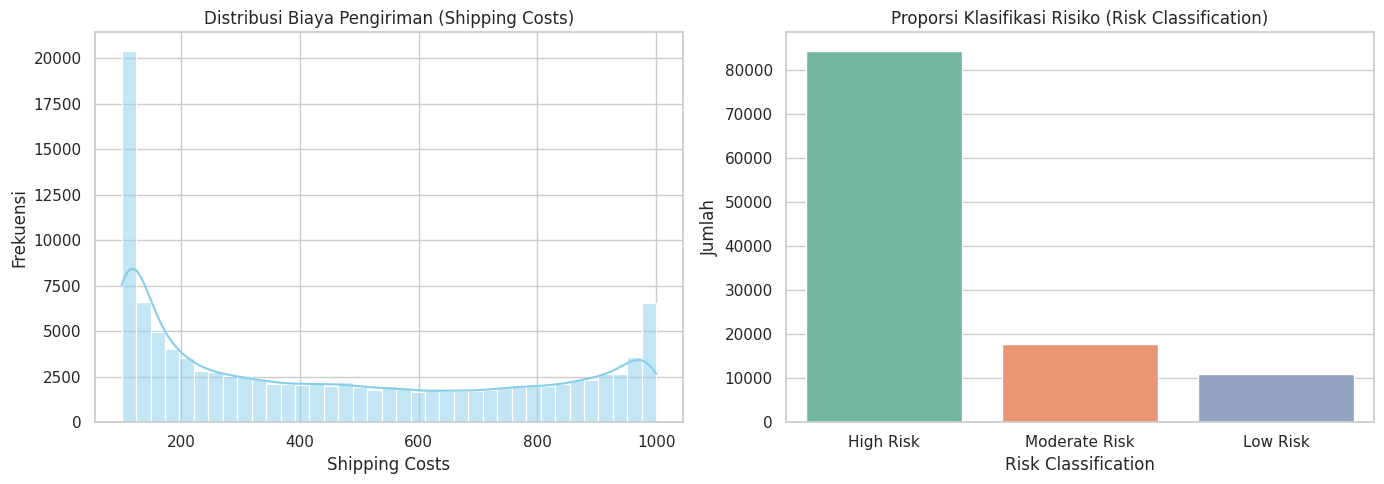

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur gaya visualisasi
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribusi Shipping Costs
sns.histplot(df['shipping_costs'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Biaya Pengiriman (Shipping Costs)')
axes[0].set_xlabel('Shipping Costs')
axes[0].set_ylabel('Frekuensi')

# Plot 2: Jumlah Data Berdasarkan Risk Classification
sns.countplot(data=df, x='risk_classification', order=df['risk_classification'].value_counts().index, ax=axes[1], palette='Set2')
axes[1].set_title('Proporsi Klasifikasi Risiko (Risk Classification)')
axes[1].set_xlabel('Risk Classification')
axes[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

**2. Analisis Efisiensi: Top 10 Negara Supplier Berdasarkan Rata-rata Biaya Pengiriman**

/tmp/ipykernel_979/242896007.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cost_countries, x='shipping_costs', y='supplier_country', palette='Reds_r')


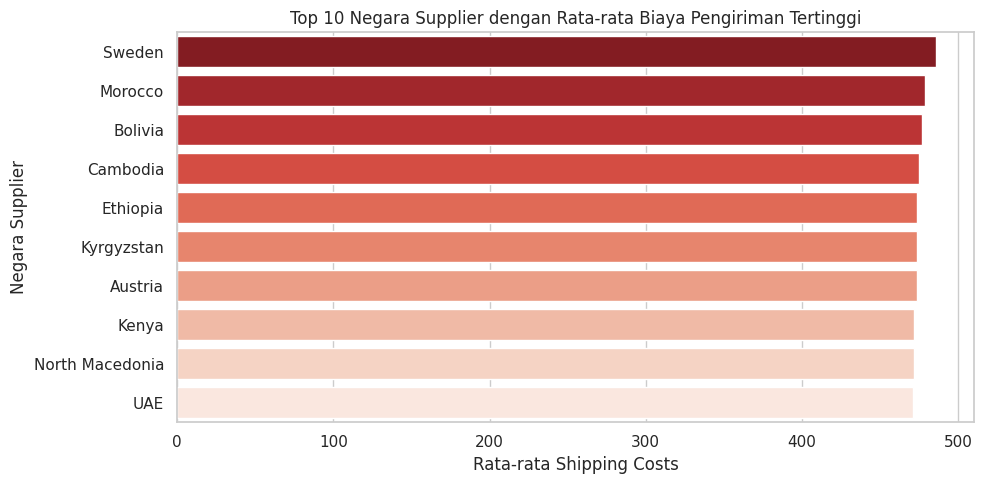

In [ ]:
# Menghitung rata-rata shipping costs per negara dan mengambil 10 teratas
top_cost_countries = df.groupby('supplier_country')['shipping_costs'].mean().reset_index()
top_cost_countries = top_cost_countries.sort_values(by='shipping_costs', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_cost_countries, x='shipping_costs', y='supplier_country', palette='Reds_r')
plt.title('Top 10 Negara Supplier dengan Rata-rata Biaya Pengiriman Tertinggi')
plt.xlabel('Rata-rata Shipping Costs')
plt.ylabel('Negara Supplier')
plt.tight_layout()
plt.show()

**3. Hubungan Antar Variabel Operasional (Heatmap Korelasi)**

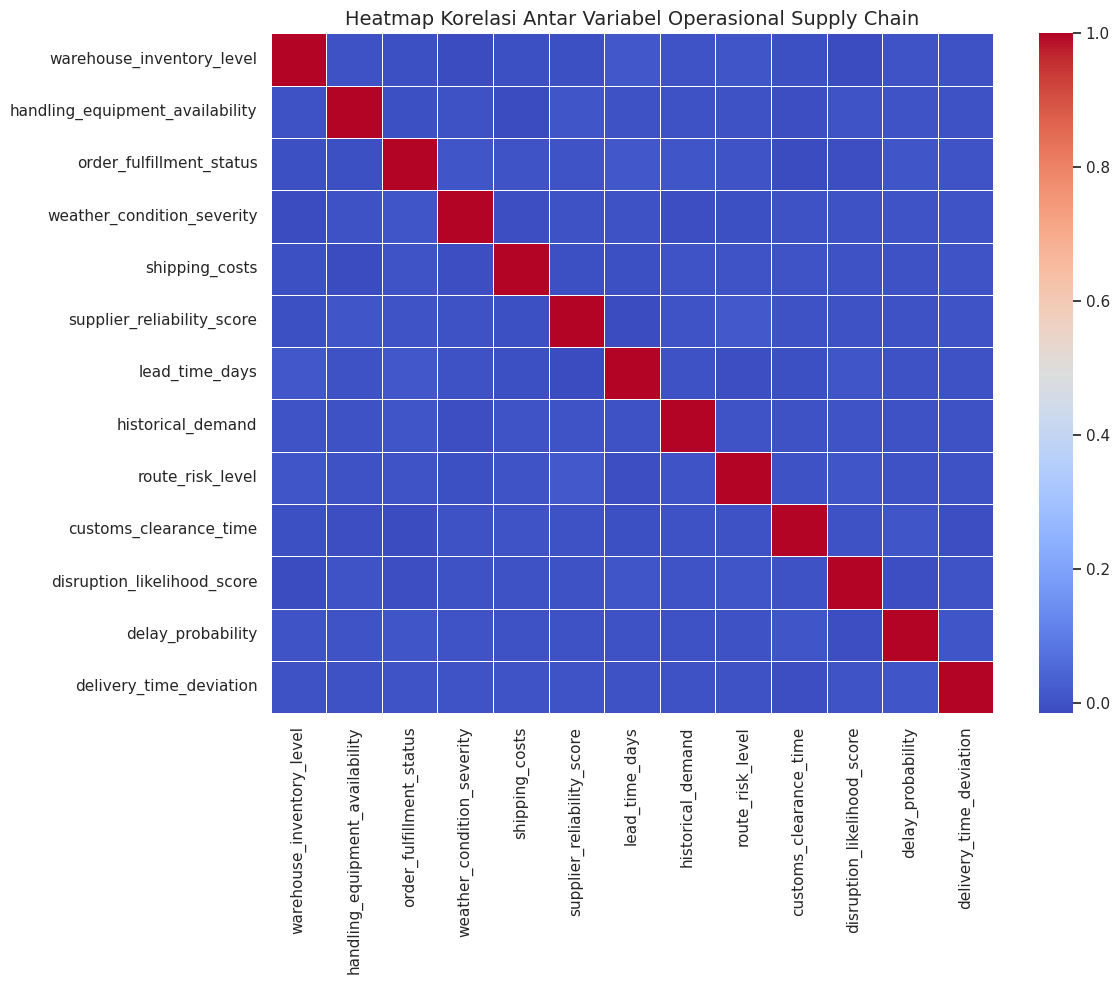

In [ ]:
plt.figure(figsize=(12, 10))
# Memilih kolom numerik utama
num_cols_corr = [
    'warehouse_inventory_level', 'handling_equipment_availability',
    'order_fulfillment_status', 'weather_condition_severity',
    'shipping_costs', 'supplier_reliability_score', 'lead_time_days',
    'historical_demand', 'route_risk_level', 'customs_clearance_time',
    'disruption_likelihood_score', 'delay_probability', 'delivery_time_deviation'
]

correlation_matrix = df[num_cols_corr].corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Heatmap Korelasi Antar Variabel Operasional Supply Chain', fontsize=14)
plt.tight_layout()
plt.show()

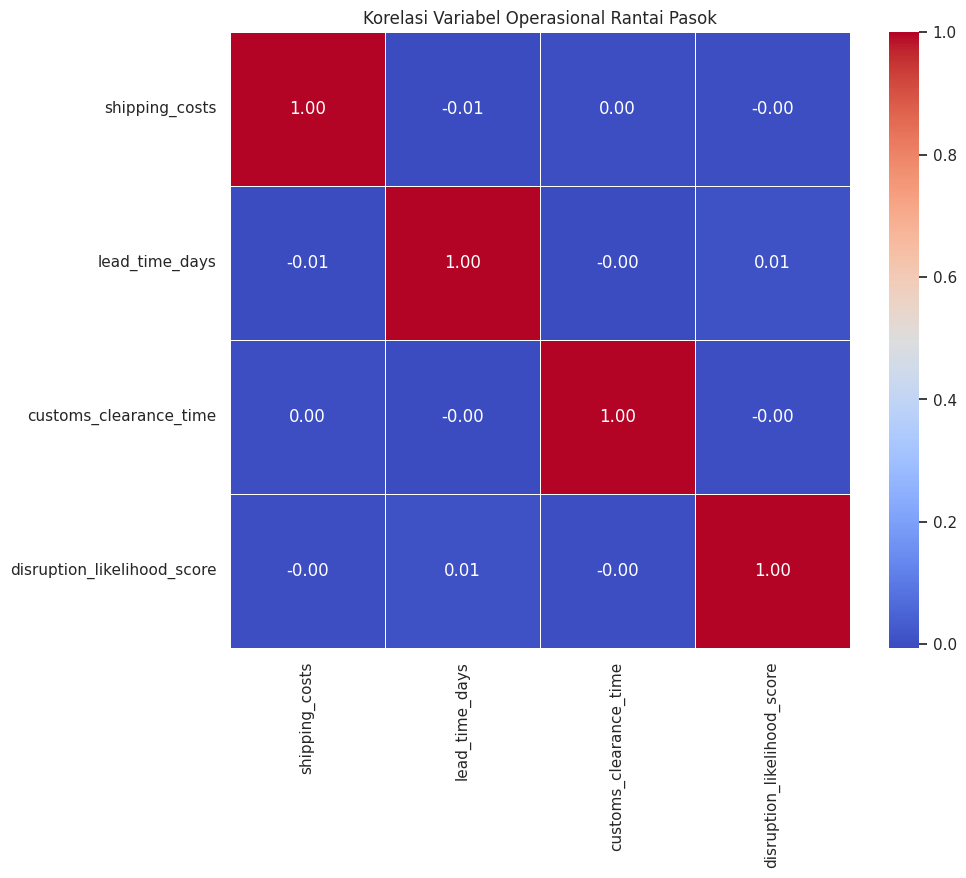

   supplier_country  shipping_costs  disruption_likelihood_score  total_orders
80           Sweden      486.004080                     0.808591           996
51          Morocco      478.711938                     0.807059          1421
8           Bolivia      477.142866                     0.818740          1013
12         Cambodia      474.876283                     0.795299           942
24         Ethiopia      473.875269                     0.798932          1472
..              ...             ...                          ...           ...
0           Algeria      446.208292                     0.798230          1025
37             Iran      445.077417                     0.804656          1071
30            Ghana      443.813976                     0.799981          1332
33            Haiti      441.269292                     0.808546           900
71     Saudi Arabia      440.005080                     0.798522          1082

[94 rows x 4 columns]


In [ ]:
# 1. Heatmap Korelasi Variabel Numerik Logistik
plt.figure(figsize=(10, 8))
numeric_cols = ['shipping_costs', 'lead_time_days', 'customs_clearance_time', 'disruption_likelihood_score']
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Variabel Operasional Rantai Pasok')
plt.show()

# 2. Rata-rata Biaya Pengiriman dan Risiko per Negara Supplier
supplier_perf = df.groupby('supplier_country').agg({
    'shipping_costs': 'mean',
    'disruption_likelihood_score': 'mean',
    'product_id': 'count' # Changed 'order_id' to 'product_id'
}).rename(columns={'product_id': 'total_orders'}).reset_index()

print(supplier_perf.sort_values(by='shipping_costs', ascending=False))